In [75]:
import pandas as pd
from pathlib import Path
import numpy as np

p = Path("data/futures")
parquet_files = sorted(p.glob("*.parquet"))
parquet_files

[PosixPath('data/futures/6E.parquet'),
 PosixPath('data/futures/6J.parquet'),
 PosixPath('data/futures/CL.parquet'),
 PosixPath('data/futures/ES.parquet'),
 PosixPath('data/futures/GC.parquet'),
 PosixPath('data/futures/NG.parquet'),
 PosixPath('data/futures/NQ.parquet'),
 PosixPath('data/futures/SI.parquet'),
 PosixPath('data/futures/YM.parquet'),
 PosixPath('data/futures/ZB.parquet'),
 PosixPath('data/futures/ZN.parquet')]

In [76]:
dfs = []
for f in parquet_files:
    df = pd.read_parquet(f)

    # flatten multi index
    df.columns = [c[0] for c in df.columns]

    df["ticker"] = f.stem
    
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    
    dfs.append(df)

df = pd.concat(dfs, ignore_index=True, sort=False)

In [77]:
earliest_per_ticker = df.groupby("ticker")["timestamp"].min().reset_index().sort_values("timestamp")
earliest_per_ticker

,ticker,timestamp
2,CL,2000-08-23
4,GC,2000-08-30
5,NG,2000-08-30
7,SI,2000-08-30
0,6E,2000-09-12
1,6J,2000-09-13
3,ES,2000-09-18
6,NQ,2000-09-18
9,ZB,2000-09-21
10,ZN,2000-09-21


In [78]:
# remove rows with timestamps before 2002-04-05
import datetime
cutoff = datetime.datetime(2002, 4, 5)
df = df[df["timestamp"] >= cutoff].reset_index(drop=True)
df

,timestamp,close,high,low,open,volume,ticker
0,2002-04-05,0.876700,0.878900,0.874800,0.875500,0,6E
1,2002-04-08,0.871600,0.876900,0.871100,0.876700,0,6E
2,2002-04-09,0.878100,0.878500,0.871200,0.872100,0,6E
3,2002-04-10,0.878000,0.880000,0.876400,0.878500,0,6E
4,2002-04-11,0.880700,0.882300,0.876800,0.878000,0,6E
...,...,...,...,...,...,...,...
65679,2025-12-12,112.343750,112.593750,112.281250,112.593750,761,ZN
65680,2025-12-15,112.453125,112.609375,112.453125,112.609375,2017,ZN
65681,2025-12-16,112.687500,112.687500,112.203125,112.562500,1340,ZN
65682,2025-12-17,112.671875,112.703125,112.421875,112.687500,1340,ZN


In [79]:
def get_agnostic_tokens(df, n_bins=10):
    # 1. Calculate True Range and ATR
    high_low = df["high"] - df["low"]
    high_pc = (df["high"] - df["close"].shift(1)).abs()
    low_pc = (df["low"] - df["close"].shift(1)).abs()

    
    tr = pd.concat([high_low, high_pc, low_pc], axis=1).max(axis=1)
    atr = tr.rolling(14).mean()
    
    # conviction and explosion (ATR may be NaN for the first rows)
    conviction = (df["close"] - df["open"]) / atr
    explosion = (df["high"] - df["low"]) / atr

    df["non_zero_volume"] = df["volume"] + 1e-12

    # relative volume
    rel_volume = df["non_zero_volume"] / (df["non_zero_volume"].rolling(50).mean())

    norm_return = pd.Series(np.where(df["close"] > df["open"], 1, 0), index=df.index)
    ret_codes = norm_return # pd.qcut(norm_return, q=n_bins, labels=False, duplicates="drop")

    # quantile bins — keep index alignment (don't dropna here)
    c_codes = pd.qcut(conviction, q=n_bins, labels=False, duplicates='drop')
    e_codes = pd.qcut(explosion, q=n_bins, labels=False, duplicates='drop')
    rv_codes = pd.qcut(rel_volume, q=n_bins, labels=False, duplicates='drop')

    # any position missing in one should be considered missing in all -> create combined mask
    mask = (c_codes == -1) | (e_codes == -1) | (rv_codes == -1)
    c_codes[mask] = None
    e_codes[mask] = None
    rv_codes[mask] = None

    c_codes = c_codes.dropna()
    e_codes = e_codes.dropna()
    rv_codes = rv_codes.dropna()

    # debug counts (should match)
    # print((c_codes == -1).sum(), (e_codes == -1).sum(), (rv_codes == -1).sum())

    # convert to strings and join into a single token
    c_s = c_codes.astype(int).astype(str)
    e_s = e_codes.astype(int).astype(str)
    rv_s = rv_codes.astype(int).astype(str)

    tokens = c_s + "_" + e_s + "_" + rv_s
    return tokens, ret_codes

number_of_classes = 2
# compute tokens per ticker and store back into the main df
df['token'] = None
for _, g in df.groupby('ticker', sort=False):
    df.loc[g.index, 'token'], df.loc[g.index, "ret"] = get_agnostic_tokens(g, n_bins=10)

df.dropna()

,timestamp,close,high,low,open,volume,ticker,token,ret
49,2002-06-13,0.941800,0.947200,0.939500,0.943700,0,6E,3_4_5,0.0
50,2002-06-14,0.945400,0.952600,0.941700,0.943000,0,6E,6_7_5,1.0
51,2002-06-17,0.942900,0.946600,0.941200,0.944800,0,6E,3_1_5,0.0
52,2002-06-18,0.947400,0.948300,0.939800,0.940600,0,6E,9_5_5,1.0
53,2002-06-19,0.952700,0.954200,0.948000,0.948000,0,6E,8_2_5,1.0
...,...,...,...,...,...,...,...,...,...
65679,2025-12-12,112.343750,112.593750,112.281250,112.593750,761,ZN,1_4_0,0.0
65680,2025-12-15,112.453125,112.609375,112.453125,112.609375,2017,ZN,2_0_0,0.0
65681,2025-12-16,112.687500,112.687500,112.203125,112.562500,1340,ZN,7_8_0,1.0
65682,2025-12-17,112.671875,112.703125,112.421875,112.687500,1340,ZN,4_3_0,0.0


In [80]:
bigger_df = pd.read_parquet("data/ibm_data.parquet").rename(columns={"symbol": "ticker"})
bigger_df["token"], bigger_df["ret"] = get_agnostic_tokens(bigger_df)
bigger_df = bigger_df.dropna()
df = bigger_df

In [81]:
# align all tickers to a common timestamp index and rebuild a compact (T_common, N, 1) integer array
# pivot tokens so each column is a ticker and index are timestamps
token_pivot = df.pivot(index="timestamp", columns="ticker", values="token").sort_index()
ret_pivot = df.pivot(index="timestamp", columns="ticker", values="ret").sort_index()


# keep only timestamps present for every ticker
common_mask = token_pivot.notna().all(axis=1) & ret_pivot.notna().all(axis=1)
T_common = int(common_mask.sum())
print("T_common:", T_common)

# restrict pivot to the common timestamps (ensures every column has the same index)
token_pivot = token_pivot.loc[common_mask]
ret_pivot = ret_pivot.loc[common_mask]

# tickers in consistent order
tickers = token_pivot.columns.tolist()
N = len(tickers)
print("N (tickers):", N, "tickers:", tickers)

token_pivot

T_common: 950858
N (tickers): 1 tickers: ['IBM']


ticker,IBM
timestamp,
2016-01-04 15:01:00+00:00,5_1_2
2016-01-04 15:02:00+00:00,0_9_9
2016-01-04 15:03:00+00:00,9_8_8
2016-01-04 15:04:00+00:00,0_9_4
2016-01-04 15:05:00+00:00,7_3_2
...,...
2024-12-31 20:58:00+00:00,2_6_9
2024-12-31 20:59:00+00:00,9_7_9
2024-12-31 21:00:00+00:00,4_0_9


In [82]:
ret_pivot

ticker,IBM
timestamp,
2016-01-04 15:01:00+00:00,1
2016-01-04 15:02:00+00:00,0
2016-01-04 15:03:00+00:00,1
2016-01-04 15:04:00+00:00,0
2016-01-04 15:05:00+00:00,1
...,...
2024-12-31 20:58:00+00:00,0
2024-12-31 20:59:00+00:00,1
2024-12-31 21:00:00+00:00,0


In [83]:
df = df.dropna()
vocab = df["token"].unique().tolist()
vocab_len = len(vocab)

T = len(token_pivot)
N = len(df["ticker"].unique())

T, N

(950858, 1)

In [84]:
# build integer mapping once (vocab is defined in the notebook)
token_to_id = {tok: i for i, tok in enumerate(vocab)}

# allocate array (T,N,1) with integer dtype
all_sequences = np.zeros((T, N, 1), dtype=np.int32)
all_targets = np.zeros((T, N))

for idx, sym in enumerate(tickers):
    seq_ids = token_pivot[sym].map(token_to_id).astype(np.int32).values
    assert seq_ids.shape[0] == T
    all_sequences[:, idx, 0] = seq_ids
    all_targets[:, idx] = ret_pivot[sym].astype(np.int32)

all_sequences.shape, all_sequences.dtype

((950858, 1, 1), dtype('int32'))

In [85]:
all_targets

array([[1.],
       [0.],
       [1.],
       ...,
       [0.],
       [0.],
       [0.]], shape=(950858, 1))

In [86]:
# build dataset

# build dataloader

# instantiate model

# train model

# inspect

In [87]:
from model.my_dataset import MyDataset
from torch.utils.data import DataLoader
from model.model_definition import SimpleTransformer
from model.training import train_loop
import torch

In [88]:
np.unique(all_targets)

array([0., 1.])

In [89]:
class_freqs = np.unique(all_targets, return_counts=True)[1]
class_freqs, number_of_classes

(array([526547, 424311]), 2)

In [ ]:
SEQ_LEN = 64
BATCH_SIZE = 1

train_dataset = MyDataset(all_sequences[:int(T*0.8)], all_targets[:int(T*0.8)], SEQ_LEN)
tmp = []
[tmp.append(train_dataset[i]) for i in range(30)]
val_dataset = MyDataset(all_sequences[int(T*0.8):], all_targets[int(T*0.8):], SEQ_LEN)
tmp2 = []
[tmp2.append(val_dataset[i]) for i in range(30, 40)]


train_dataloader = DataLoader(tmp, batch_size=BATCH_SIZE)
val_dataloader = DataLoader(tmp2, batch_size=BATCH_SIZE)



# pass frequencies to the model (as a list)
model = SimpleTransformer(vocab, SEQ_LEN, number_of_classes, symbol_count=N, output_class_freq=class_freqs, attention_layers=2, hidden_dim=32)

res = train_loop(model, train_dataloader, val_dataloader, 100, 4e-6, 1e-5, torch.device("cpu"), "checkpoint", 10)

Training on device: cpu
Trainable parameters: 55138
Training samples: 30, Validation samples: 10
--------------------------------------------------------------------------------
New best model saved at epoch 1
Epoch: 0 | Train loss: 0.8870834251244862 | Val loss: 0.8128332257270813
Epoch: 1 | Train loss: 0.8660171250502269 | Val loss: 0.8171415090560913
Epoch: 2 | Train loss: 0.8576117316881816 | Val loss: 0.8215126693248749
Epoch: 3 | Train loss: 0.8508159617582957 | Val loss: 0.8231717467308044
Epoch: 4 | Train loss: 0.8406124194463094 | Val loss: 0.8230400085449219
Epoch: 5 | Train loss: 0.8269022484620412 | Val loss: 0.8211885631084442
Epoch: 6 | Train loss: 0.8248134553432465 | Val loss: 0.8189170837402344
Epoch: 7 | Train loss: 0.8172456761201222 | Val loss: 0.8162588536739349
New best model saved at epoch 9
Epoch: 8 | Train loss: 0.81491286555926 | Val loss: 0.8125945627689362
New best model saved at epoch 10
Epoch: 9 | Train loss: 0.8105397522449493 | Val loss: 0.80831238627433

In [91]:
import matplotlib.pyplot as plt

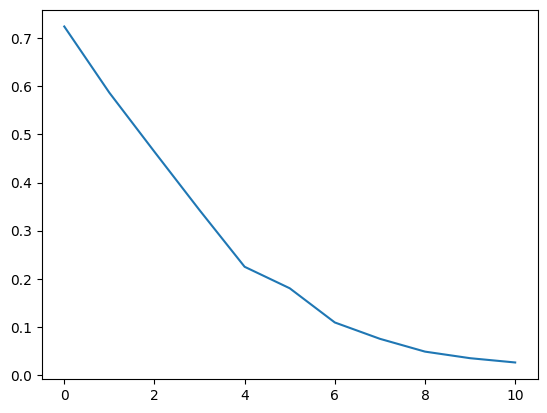

In [92]:
plt.plot(res["history"]["train_loss"])

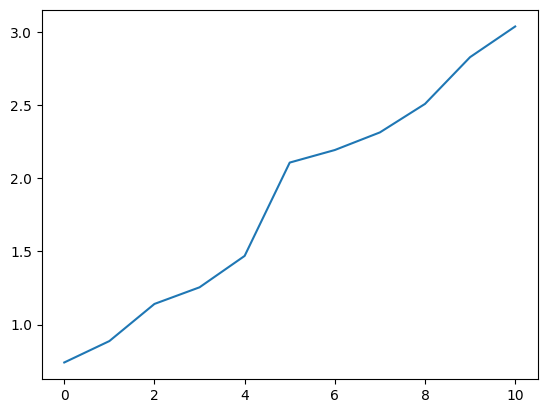

In [93]:
plt.plot(res["history"]["val_loss"])

In [94]:
model.eval()
with torch.no_grad():
    for x_batch, y_batch in val_dataloader:
        preds, _ = model(x_batch)
        # print(preds)
        break
preds

tensor([[[[0.5321, 0.4679]],

         [[0.5304, 0.4696]],

         [[0.6512, 0.3488]],

         [[0.2459, 0.7541]],

         [[0.4566, 0.5434]],

         [[0.4132, 0.5868]],

         [[0.4145, 0.5855]],

         [[0.5546, 0.4454]],

         [[0.4209, 0.5791]],

         [[0.3257, 0.6743]],

         [[0.3690, 0.6310]],

         [[0.4532, 0.5468]],

         [[0.6384, 0.3616]],

         [[0.4435, 0.5565]],

         [[0.5462, 0.4538]],

         [[0.5629, 0.4371]],

         [[0.4492, 0.5508]],

         [[0.3538, 0.6462]],

         [[0.8375, 0.1625]],

         [[0.3658, 0.6342]],

         [[0.7121, 0.2879]],

         [[0.5805, 0.4195]],

         [[0.4163, 0.5837]],

         [[0.4701, 0.5299]],

         [[0.3195, 0.6805]],

         [[0.2932, 0.7068]],

         [[0.3772, 0.6228]],

         [[0.3593, 0.6407]],

         [[0.4087, 0.5913]],

         [[0.7223, 0.2777]],

         [[0.7185, 0.2815]],

         [[0.5258, 0.4742]],

         [[0.4872, 0.5128]],

         [

In [95]:
preds = preds.squeeze(0)

In [96]:
preds = preds.view(preds.shape[0]*preds.shape[1], preds.shape[2])

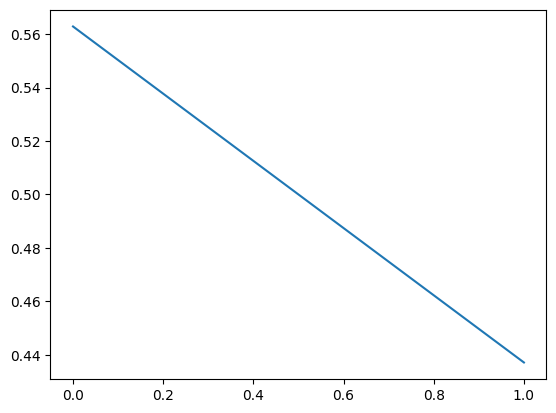

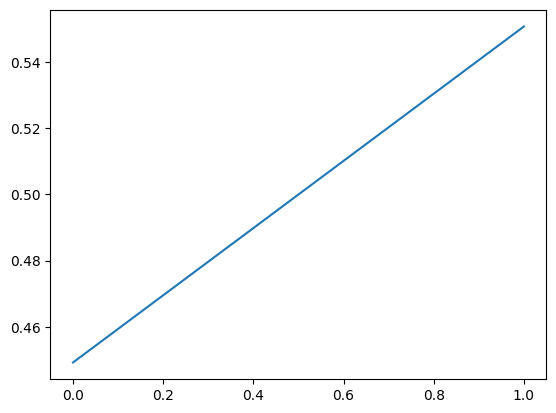

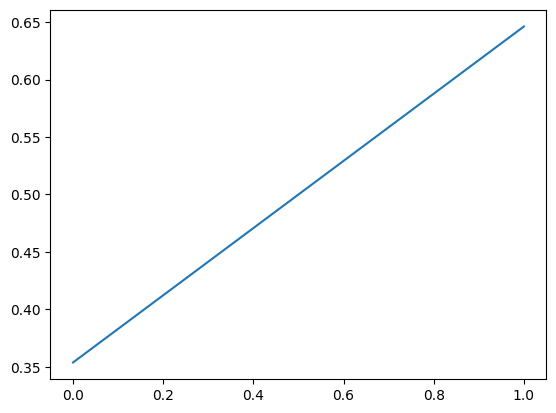

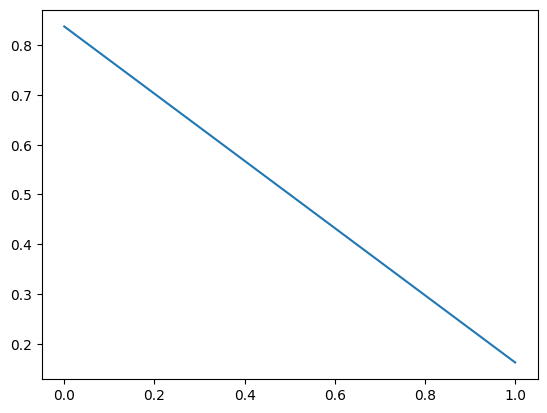

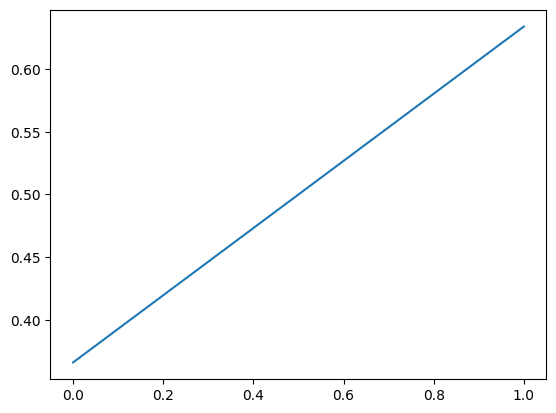

In [97]:
for i in range(15, 20):
    plt.plot(preds[i])
    plt.show()